# Day 3 - Tuning and Evaluation

We build a pipeline that takes **raw** (cleaned) data, tune it, fix the churn-class recall with `class_weight="balanced"`, evaluate it properly, and save it for the app.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)

from src.data_loader import load_raw_data
from src.preprocessing import clean_data, split_data
from src.model import build_pipeline, NUMERIC_COLS, save_model

df = clean_data(load_raw_data())
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = split_data(X, y)

categorical_cols = [c for c in X.columns if c not in NUMERIC_COLS]
print("numeric cols    :", NUMERIC_COLS)
print("categorical cols:", len(categorical_cols))

numeric cols    : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical cols: 15


## Hyperparameter tuning

`GridSearchCV` tries each value of the regularization strength `C` with 5-fold cross-validation and keeps the best. `class_weight="balanced"` is already baked into the pipeline.

In [2]:
pipe = build_pipeline(categorical_cols)
param_grid = {"clf__C": [0.01, 0.1, 1, 10]}
search = GridSearchCV(pipe, param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
search.fit(X_train, y_train)

print("best params   :", search.best_params_)
print("best CV ROC-AUC:", round(search.best_score_, 4))
best_model = search.best_estimator_

best params   : {'clf__C': 10}
best CV ROC-AUC: 0.8456


## Evaluation on the test set

Look at **recall for class `1`** and compare it to Day 2's 0.51. With `class_weight="balanced"` it should jump a lot (and precision drops, the tradeoff you predicted).

In [3]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
print("test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print(classification_report(y_test, y_pred))

test ROC-AUC: 0.8406
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## ROC curve

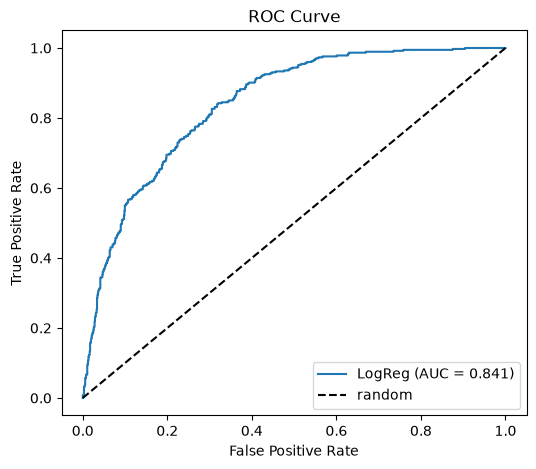

In [4]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LogReg (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Your task - confusion matrix

Plot the confusion matrix of `y_test` vs `y_pred` in the cell below.

Hint: `ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Stay", "Churn"])`

Then answer in one sentence: of the customers who actually churned, roughly how many did the model **catch** (bottom-right) versus **miss** (bottom-left)?

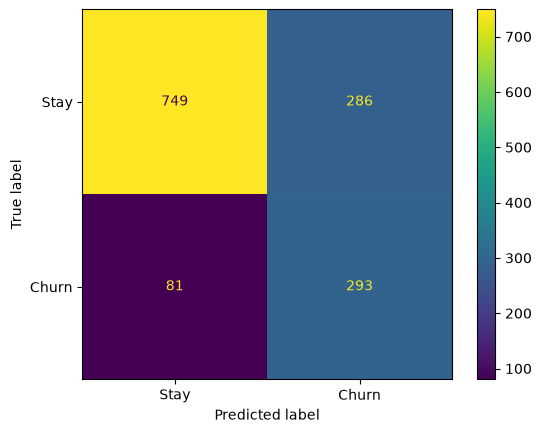

In [5]:
# TODO (your task): plot the confusion matrix for y_test vs y_pred
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Stay", "Churn"])


## Save the model for the app

In [6]:
save_model(best_model)
print("saved to models/churn_pipeline.joblib")

saved to models/churn_pipeline.joblib
